# Beam Sweeping in a DeepMIMO Scenario
This notebook demonstrates beam sweeping in a DeepMIMO scenario by transmitting a set of CSI-RS resources and using the corresponding CRI reports.


In [1]:
import numpy as np

from neoradium import DeepMimoData, BandwidthPart, AntennaPanel
from neoradium import CsiRs, CsiRsSet, CsiRsConfig, CsiReport, CsiReportMan
from neoradium.utils import toDb

In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
dmData = DeepMimoData("asu_campus_3p5")
dmData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%



In the following cell, we select an arbitrary UE position and use the ``channelForPoints`` method of the ``DeepMimoData`` class to obtain a channel model between the base station and the UE.


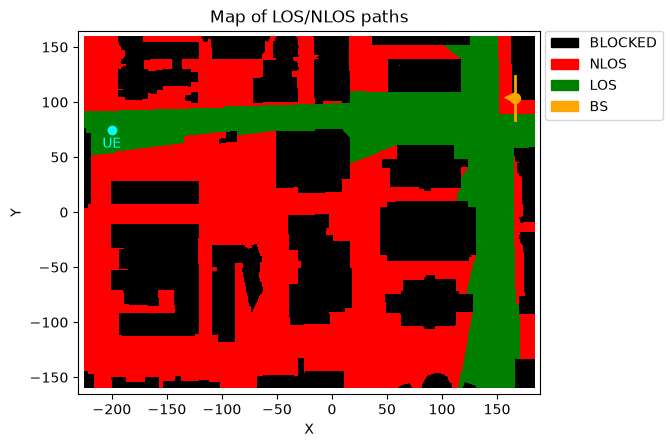

In [3]:
# Create a bandwidth part
bwp = BandwidthPart(numRbs=24, spacing=30)

# Select a UE position
uePosition = [-200,75]      # Try other points such as [120,60] or [125,125]

# Create a channel model between the base station and the specified UE
bearingAngle = 180
channel = dmData.channelForPoints(uePosition, bwp,
                                  txAntenna = AntennaPanel([1,4], polarization='x'),# 8 TX antennas
                                  txOrientation = [bearingAngle,0,0],                
                                  rxAntenna = AntennaPanel([1,1], polarization='x', # 2 RX antennas
                                                           beamWidth=[65,360]),     # Omnidirectional
                                  normalizeGains=False)                             # Do not normalize gains
# channel.print()                                           # Uncomment to print the channel information

# Draw the map to show the base station and the UE
ax = dmData.drawMap("LOS-NLOS")                             # Draw the scenario map
dmData.drawBsPanel(ax, bearingAngle)                        # Draw the base station antenna panel
ax.scatter(x=[uePosition[0]], y=[uePosition[1]], c="cyan")  # Draw the UE position
ax.annotate("UE", uePosition, textcoords="offset points",   # Annotate the UE position
            xytext=(0,-13), ha='center', color="cyan");


In [4]:
# Create a beam-sweeping CSI-RS configuration
# For this beam-sweeping experiment, we use:
# - 8 beams for sweeping
# - 8 CSI-RS objects with resource IDs 1 to 8
# - CSI-RS resources at symbol 4 and resource elements 2 to 9
# - One NZP CSI-RS resource set containing all 8 sweeping resources
numSweep = 8
sweepResources = []
for i in range(numSweep):
    sweepResources += [ CsiRs(resourceId=i+1, numPorts=1, symbols=[4],
                              freqMap="".join([str(int(x)) for x in np.eye(12)[i+2]])[::-1]) ] # REs 2 to 9

sweepSet = CsiRsSet("NZP", bwp, resourceType="periodic", rsId=1, period=20*(bwp.u+1), csiRsList=sweepResources)
sweepConfig = CsiRsConfig([sweepSet])
# sweepConfig.print()                                       # Uncomment to print the CSI-RS configuration

# Create a CSI report object for CRI reporting
sweepReport = CsiReport(sweepSet, reportId=sweepSet.rsId+10, quantity="Cri")
# Create a CSI report manager (upDelay=0 means no uplink delay and the report becomes available immediately)
sweepReportMan = CsiReportMan([sweepReport], upDelay=0)
sweepReportMan.print()



CSI Report Manager Properties:
  upDelay:              0
  Num Reports:          1
  CSI Report 11:
    reportId:           11
    reportType:         periodic
    period:             5
    offset:             0
    quantity:           Cri



Beam information:
  Beam   Theta    Phi    Pol
  ----   -----   -----   ---
   0     90.0    -60.0    x
   1     90.0    -38.2    x
   2     90.0    -21.8    x
   3     90.0     -7.1    x
   4     90.0      7.1    x
   5     90.0     21.8    x
   6     90.0     38.2    x
   7     90.0     60.0    x

Resource elements in 'txGrid':
    GridSize:       32256
    UNASSIGNED:     30720
    CSIRS_NZP(1):   192
    CSIRS_NZP(2):   192
    CSIRS_NZP(3):   192
    CSIRS_NZP(4):   192
    CSIRS_NZP(5):   192
    CSIRS_NZP(6):   192
    CSIRS_NZP(7):   192
    CSIRS_NZP(8):   192

CRI Info:
    CRI:             5
    Best beam index: 4
    Best beam:       𝛳=90.00°, 𝝋=7.11°
    RSRP:            -60.84 dB


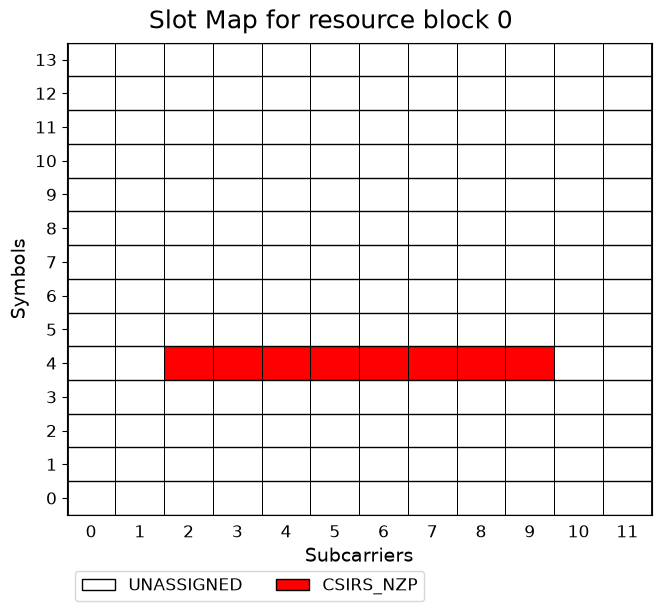

In [5]:
# Get the channel matrix between the base station and the UE from the channel model
channelMatrix = channel.getChannelMatrix()

csiRsResources = sweepConfig.getResources()                             # Get CSI-RS resource information
setResources = csiRsResources[ sweepSet.rsId ]                          # Get the resources for beam sweeping (by ID)
sweepWs, sweepBeams = channel.txAntenna.getSweepingBeams(1, numSweep)   # Get beam angles and precoders from TX panel
print("Beam information:")
print("  Beam   Theta    Phi    Pol")
print("  ----   -----   -----   ---")
for i in range(numSweep):
    print(f"   {i}    {np.round(sweepBeams[0][i],1):5.1f}    {np.round(sweepBeams[1][i],1):5.1f}    {sweepBeams[2][i]}")

# Create a transmitted resource grid and precode the CSI-RS resources using the
# precoders obtained above. Then set the corresponding resource elements in
# txGrid to the precoded CSI-RS values.
txGrid = bwp.createGrid(channel.txAntenna.numEl)
for resourceId, (lIdx, kIdx, sweepReValues) in setResources.items():
    b = resourceId-1                                                    # Beam index (= resource ID - 1)
    w = sweepWs[:,b:b+1]   # nt x 1                                     # Precoding vector for this beam
    txGrid[:,lIdx, kIdx] = (w @ sweepReValues, "CSIRS_NZP", resourceId) # Precode the resources in txGrid

txGrid.drawMap()                                            # Draw a map of txGrid for the first TX antenna port
gridStats = txGrid.getStats()                               # Get statistics. This shows the number of REs in the
print("\nResource elements in 'txGrid':")                   # full resource grid allocated to each CSI-RS
for k,v in gridStats.items():
    print(f"    {k+":":15s} {v}")

# Pass txGrid through the channel and add noise
rxGrid = txGrid.applyChannel(channelMatrix)                 # Apply the channel to the precoded resources (frequency domain)
noisyRxGrid = rxGrid.addNoise(snrDb=10, useRxPower=True)    # Add noise

# Process CSI-RS at UE:
sweepReportMan.processRxGrid(noisyRxGrid, csiRsResources)   # Process the CSI-RS and prepare the feedback

# For this example we assume the feedback is available immediately
csiReportInfo = sweepReportMan.getFeedback()                # Get all available CSI reports from CsiReport objects
csiFeedback = csiReportInfo[ sweepReport.reportId ]         # Get the CSI feedback for the beam sweeping (by ID)
cri = csiFeedback.cri.cri
print(f"\nCRI Info:")
print(f"    CRI:             {cri}")
print(f"    Best beam index: {cri-1}")
print(f"    Best beam:       𝛳={sweepBeams[0][cri-1]:.2f}°, 𝝋={sweepBeams[1][cri-1]:.2f}°")
print(f"    RSRP:            {csiFeedback.cri.rsrp:.2f} dB")


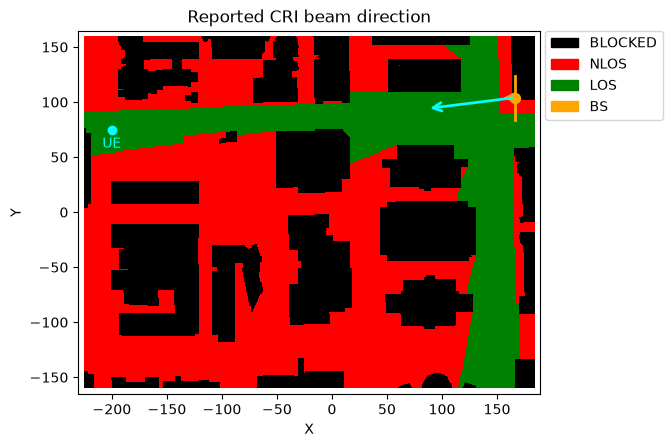

In [6]:
# Draw the map again, this time with an arrow showing the direction of the CRI beam
beamAngle = sweepBeams[1][cri-1]                                # Angle of the reported CRI beam
ax = dmData.drawMap("LOS-NLOS")                                 # Draw the scenario map
dmData.drawBsPanel(ax, bearingAngle)                            # Draw the base station antenna panel
theta, phi = AntennaPanel.local2Global(sweepBeams[0][cri-1], sweepBeams[1][cri-1], channel.txOrientation)
dmData.drawBeamArrow(ax, phi, color="cyan")                     # Draw the CRI beam arrow
ax.scatter(x=[uePosition[0]], y=[uePosition[1]], c="cyan")      # Draw the UE position
ax.annotate("UE", uePosition, textcoords="offset points",       # Annotate the UE position
            xytext=(0,-13), ha='center', color="cyan")
ax.set_title("Reported CRI beam direction");                    # Set the map title
